# Tổng quan
## Giới thiệu

- Titanic - Machine Learning from Disaster là một trong những cuộc thi khởi đầu (Getting Started Competition) phổ biến nhất trên Kaggle, được coi là "Hello world" của Khoa học Dữ liệu (Data Science) và Học máy (Machine Learning) với dữ liệu dạng bảng.

- Bài toán dựa trên thảm kịch đắm tàu RMS Titanic vào ngày 15 tháng 4 năm 1912, một trong những vụ đắm tàu nổi tiếng nhất lịch sử. Do không đủ thuyền cứu sinh, 1502 trong số 2224 hành khách và thủy thủ đoàn đã thiệt mạng.

- Mặc dù sự sống sót có yếu tố may rủi, nhưng một số nhóm người có vẻ có nhiều khả năng sống sót hơn những nhóm khác (ví dụ: phụ nữ, trẻ em, hành khách hạng nhất).

## Mục tiêu bài toán

- Mục tiêu của dự án là xây dựng một mô hình dự đoán để trả lời câu hỏi: "Những người như thế nào có khả năng sống sót sau thảm họa Titanic?"

- Đây là một bài toán phân loại nhị phân (Binary Classification), trong đó mô hình cần dự đoán xem một hành khách có sống sót hay không

## Bộ dữ liệu Titanic
Bộ dữ liệu cung cấp thông tin chi tiết về các hành khách trên tàu, bao gồm các đặc trưng chính (features) như:
- Survived: Cột mục tiêu (Target Label). Giá trị $0$ = Không sống sót, $1$ = Sống sót.
- Pclass: Hạng vé (tượng trưng cho địa vị kinh tế-xã hội). $1$ = Hạng Nhất (Upper), $2$ = Hạng Trung (Middle), $3$ = Hạng Thấp (Lower).
- Sex: Giới tính.Age: Tuổi của hành khách.
- SibSp: Số lượng anh/chị/em hoặc vợ/chồng cùng đi trên tàu.
- Parch: Số lượng cha mẹ hoặc con cái cùng đi trên tàu.
- Fare: Giá vé.Embarked: Cảng lên tàu.Và một số cột thông tin khác như Name (Tên), Ticket (Số vé), Cabin (Cabin).

# Nội dung

## 1. Các thư viện sử dụng

In [131]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
from IPython import display

**numpy**: thư viện tính toán số học, hỗ trợ xử lí mảng, ma trận và các phép toán phức tạp.
ứng dựng EDA: Xử lí giá trị thiếu, tính toán thống kê, phân tích đa biến.

**matplotlib**: thư viện trực quan hóa dữ liệu, tạo các biểu đồ như bar plot, scatter plot, boxplot.
ứng dụng EDA: Vẽ histogram trong phân tích đơn biến, đa biến

**pandas**: Thư viện quản lý và thao tác dữ liệu dạng bảng (DataFrame), hỗ trợ đọc, xử lí, và phân tích dữ liệu
ứng dụng EDA: đọc dữ liệu từ CSV, phân tích đơn biến và đa biến.

**sklearn.preprocessing.LabelEncoder**: chuyển đổi biến categorical thành số

**sklearn.preprocessing.StandardScaler**: Chuẩn hóa dữ liệu số về dạng zero mean và unit variance ( (x - mean) / std ), phù hợp cho các mô hình ML nhạy với scale (như SVM, Logistic Regression).

**sklearn.preprocessing.MinMaxScaler**: Chuẩn hóa dữ liệu số về khoảng [0, 1] ( (x - min) / (max - min) ), phù hợp cho các mô hình cần dữ liệu giới hạn (như Neural Networks).

**seaborn**: Thư viện trực quan hóa dữ liệu nâng cao, dựa trên Matplotlib, cung cấp giao diện đẹp và dễ dùng cho các biểu đồ phức tạp.


## 2. EDA

### 2.1 Hiểu và làm sạch dữ liệu 

#### a. Tải và Kiểm tra Cấu trúc Dữ liệu

In [132]:
df_train=pd.read_csv("train.csv")
df_test=pd.read_csv("test.csv")

**Xem 5 hàng đầu tiên và cuối cùng**

In [133]:
display.display(df_train.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [134]:
display.display(df_test.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


**Kiểm tra kiểu dữ liệu của từng cột (số nguyên, số thực, đối tượng/chuỗi).**

In [135]:
print("Tap train")
(df_train.info())



Tap train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [136]:
print("Tap test")
display.display(df_test.info())

Tap test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


None

**Xem thống kê cơ bản (trung bình, độ lệch chuẩn, tứ phân vị) của các cột số**

In [137]:
print("thong ke mo ta: ")
display.display(df_train.describe())

thong ke mo ta: 


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Nhận xét** 
- Bộ dữ liệu gồm 891 hành khách, trong đó có 38.4% sống sót và 61.6% tử vong → tỷ lệ sống sót thấp.
PassengerId

Chỉ là mã định danh, không có ý nghĩa thống kê.

Survived

Trung bình 0.38 → 38% hành khách sống sót.

Cho thấy đa số hành khách không sống sót sau vụ chìm tàu.

Pclass (Hạng vé)

Trung bình 2.31 → đa phần hành khách thuộc hạng 2 và 3.

Có thể suy ra hành khách hạng cao (1) ít hơn và có khả năng sống sót cao hơn.

Age (Tuổi)

Tuổi trung bình khoảng 29.7, độ lệch chuẩn 14.5 → độ tuổi khá đa dạng.

Có nhiều người trưởng thành trẻ tuổi, một số ít là trẻ em và người già.

Có 177 giá trị bị thiếu (714/891).

SibSp (Anh chị em/vợ chồng đi cùng)

Trung bình 0.52 → đa số đi một mình.

Có một vài người đi cùng nhiều thân nhân (tối đa 8).

Parch (Cha mẹ/con đi cùng)

Trung bình 0.38 → phần lớn không đi cùng cha mẹ hay con cái.

Một số ít đi cùng gia đình (tối đa 6).

Fare (Giá vé)

Trung bình 32.20, độ lệch chuẩn 49.69 → chênh lệch giá vé lớn.

Giá vé thấp nhất 0, cao nhất 512.33, thể hiện chênh lệch rõ rệt giữa các tầng lớp.

#### b Xử lí giá trị thiếu


In [138]:
print(df_train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


PassengerId, Survived, Pclass, Name, Sex, SibSp, Parch, Ticket, Fare
→ Không có giá trị bị thiếu (0 missing)
→ Các cột này đầy đủ dữ liệu, có thể sử dụng ngay để phân tích.

Age
→ Thiếu 177 giá trị (~19.9% dữ liệu).
→ Cần xử lý missing values (ví dụ: thay bằng trung bình, trung vị, hoặc dự đoán dựa trên các đặc trưng khác).

Cabin
→ Thiếu 687 giá trị (~77% dữ liệu).
→ Tỷ lệ thiếu rất cao, nên khó sử dụng trực tiếp. Có thể:

Loại bỏ cột Cabin khỏi mô hình, hoặc

Tách đặc trưng từ Cabin (ví dụ: chỉ lấy ký tự đầu để biểu thị “khu khoang”).

Embarked
→ Thiếu 2 giá trị (rất nhỏ, ~0.2%).
→ Có thể điền bằng giá trị phổ biến nhất (mode).

In [139]:
age_median =df_train['Age'].median()
df_train  ['Age'].fillna(age_median, inplace=True)
print(f"\nĐã điền các giá trị thiếu trong cột 'Age' bằng trung vị: {age_median}")


Đã điền các giá trị thiếu trong cột 'Age' bằng trung vị: 28.0


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27416\1033603155.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train  ['Age'].fillna(age_median, inplace=True)


In [140]:
embarked_mode = df_train['Embarked'].mode()[0] # .mode() trả về một Series, lấy phần tử đầu tiên
df_train['Embarked'].fillna(embarked_mode, inplace=True)
print(f"Đã điền các giá trị thiếu trong cột 'Embarked' bằng mode: {embarked_mode}")

Đã điền các giá trị thiếu trong cột 'Embarked' bằng mode: S


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27416\698731936.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Embarked'].fillna(embarked_mode, inplace=True)


In [141]:
df_train['Has_Cabin'] = np.where(df_train['Cabin'].isnull(), 0, 1)
df_train.drop('Cabin', axis=1, inplace=True)
print("Đã tạo cột 'Has_Cabin' (1 nếu có, 0 nếu không) và xóa cột 'Cabin' gốc.")

Đã tạo cột 'Has_Cabin' (1 nếu có, 0 nếu không) và xóa cột 'Cabin' gốc.


In [142]:
display.display(df_train.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


#### c. Xử lý Giá trị Ngoại lai (Outliers)

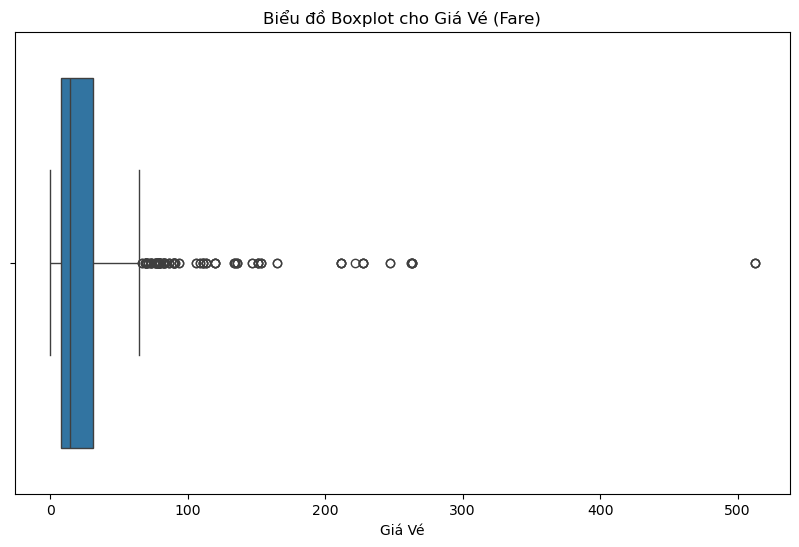

In [143]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_train['Fare'])
plt.title('Biểu đồ Boxplot cho Giá Vé (Fare)')
plt.xlabel('Giá Vé')
plt.show()

**Nhận xét:** Biểu đồ cho thấy có nhiều giá trị vé rất cao. Trong giai đoạn này, chúng ta chỉ quan sát chúng. Việc xử lý (ví dụ: loại bỏ hoặc biến đổi log) sẽ được cân nhắc ở giai đoạn xây dựng mô hình.

### 2.2 Phân tích đơn biến

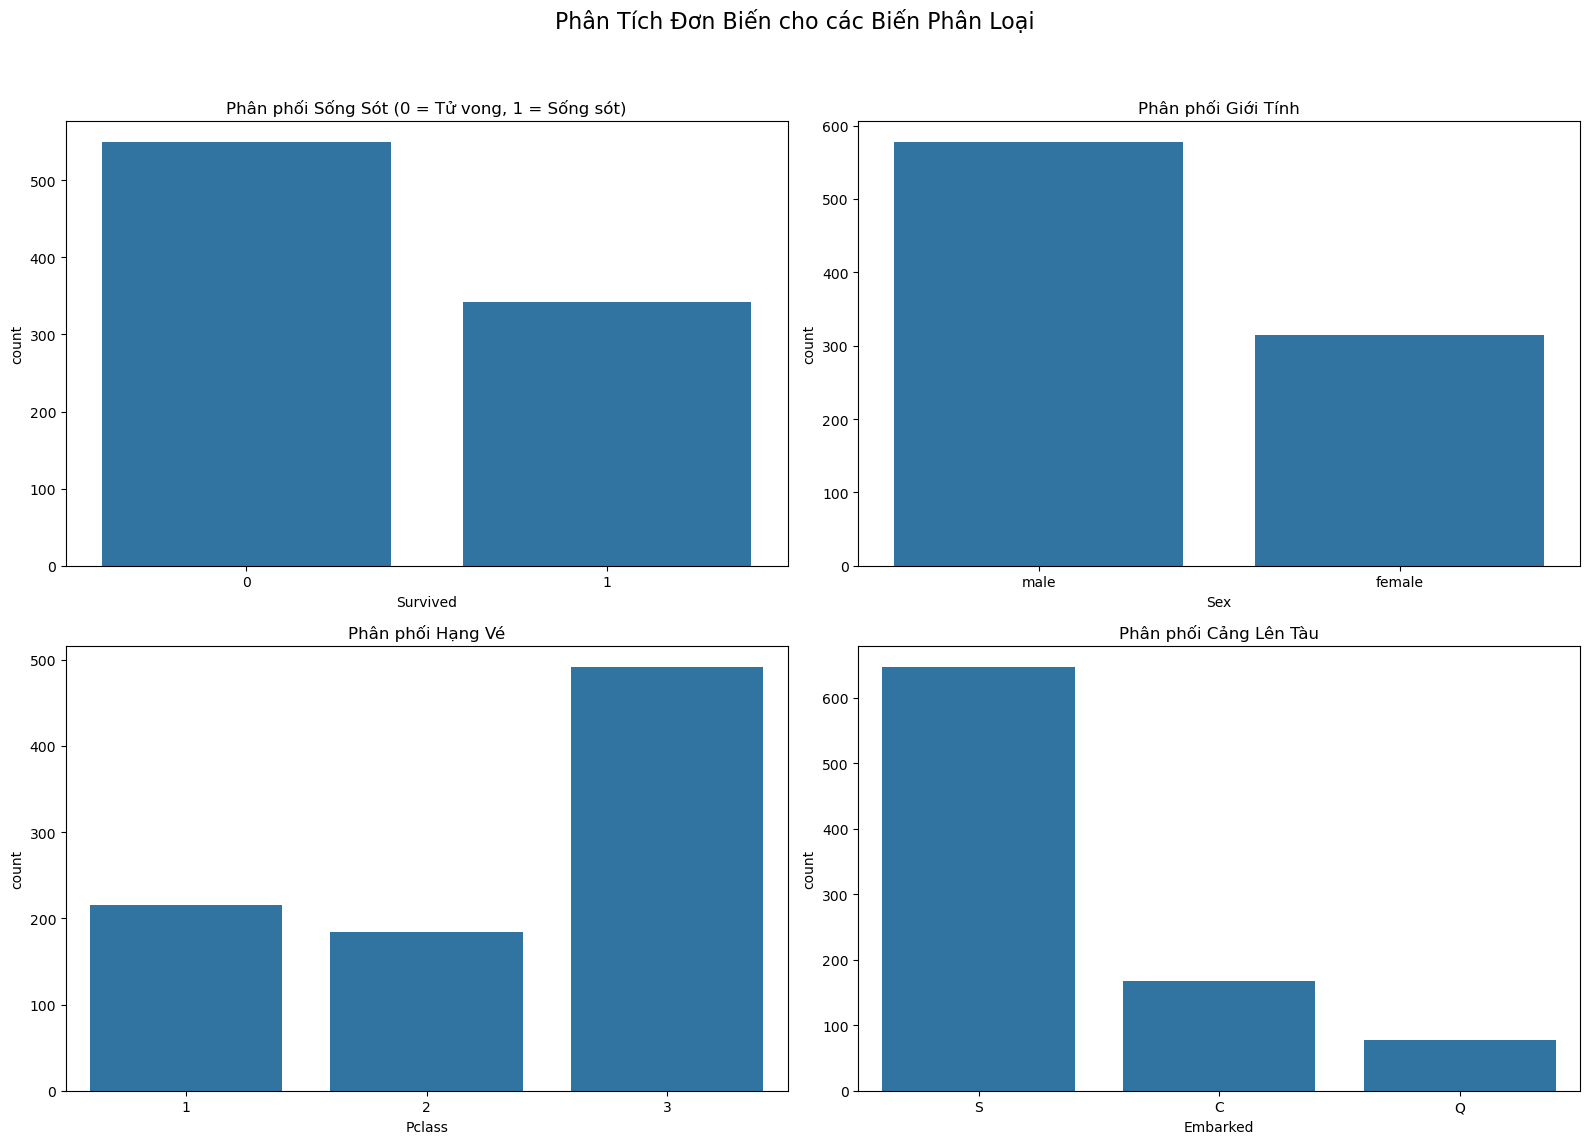

In [144]:
# Vẽ biểu đồ cột cho các biến phân loại
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân Tích Đơn Biến cho các Biến Phân Loại', fontsize=16)

sns.countplot(ax=axes[0, 0], x='Survived', data=df_train)
axes[0, 0].set_title('Phân phối Sống Sót (0 = Tử vong, 1 = Sống sót)')

sns.countplot(ax=axes[0, 1], x='Sex', data=df_train)
axes[0, 1].set_title('Phân phối Giới Tính')

sns.countplot(ax=axes[1, 0], x='Pclass', data=df_train)
axes[1, 0].set_title('Phân phối Hạng Vé')

sns.countplot(ax=axes[1, 1], x='Embarked', data=df_train)
axes[1, 1].set_title('Phân phối Cảng Lên Tàu')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**1. Survived (Sống sót: 0 = Tử vong, 1 = Sống sót)**

Biểu đồ cho thấy số người tử vong (0) nhiều hơn rõ rệt so với số người sống sót (1).

Tỷ lệ sống sót chỉ khoảng 38%, trùng khớp với thống kê trung bình (mean = 0.3838).
→ Nhận xét: Tỷ lệ sống sót thấp, chứng tỏ số lượng xuồng cứu sinh hoặc cơ hội thoát nạn không đủ cho tất cả hành khách.

**2. Sex (Giới tính)**

Biểu đồ cho thấy nam giới chiếm đa số so với nữ giới.

Tuy nhiên, khi kết hợp với biến Survived (ở bước phân tích hai biến), ta thường thấy phụ nữ có tỷ lệ sống cao hơn nhiều (“women and children first”).
→ Nhận xét: Dữ liệu mất cân bằng về giới tính, và giới tính có thể là yếu tố quan trọng ảnh hưởng đến khả năng sống sót.

**3. Pclass (Hạng vé)**

Hạng 3 (Pclass = 3) chiếm tỷ lệ lớn nhất trong tập dữ liệu, kế đến là hạng 1 và 2.

Người hạng 3 thường là hành khách bình dân hoặc tầng lớp lao động, có chỗ ở ở tầng thấp hơn.
→ Nhận xét: Dữ liệu nghiêng về hạng thấp, điều này có thể giải thích tỷ lệ tử vong cao vì người hạng thấp thường ở xa khu vực xuồng cứu sinh.

**4. Embarked (Cảng lên tàu)**


Có ba cảng chính: S (Southampton), C (Cherbourg), và Q (Queenstown).

Biểu đồ cho thấy phần lớn hành khách lên tàu tại Southampton (S).
→ Nhận xét:

Southampton là cảng chính, nên hành khách từ đây chiếm đa số.

Cherbourg và Queenstown có ít hơn nhiều, nhưng những người lên tại Cherbourg thường có vé hạng cao hơn (thường là quý tộc hoặc người giàu).

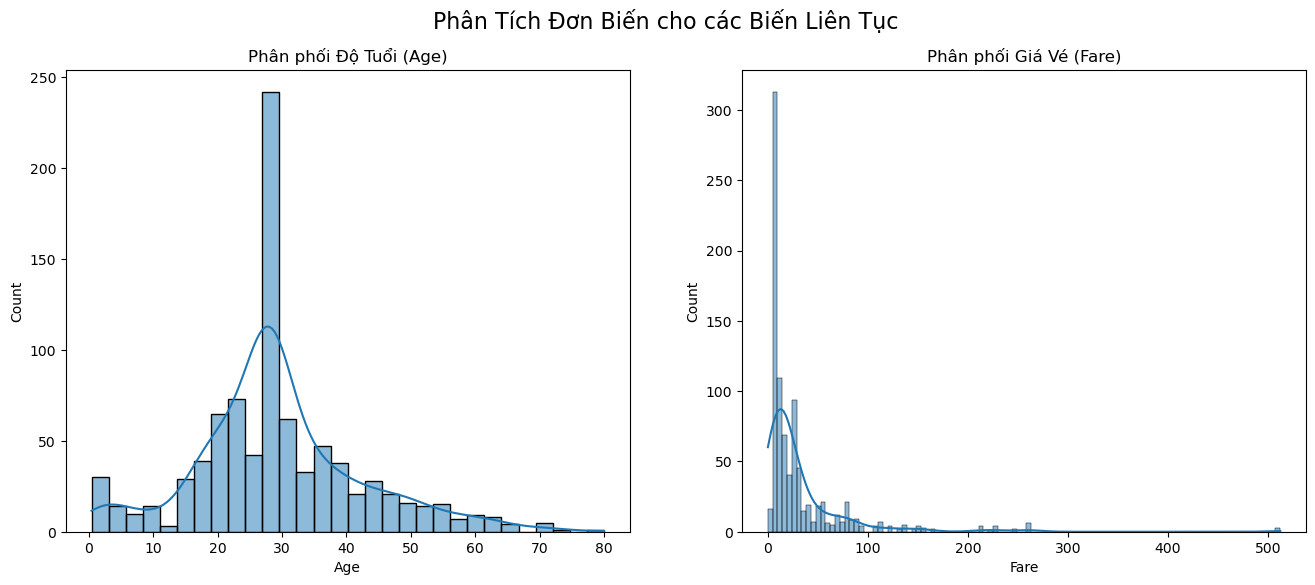

In [145]:
# Vẽ biểu đồ phân phối cho các biến liên tục
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân Tích Đơn Biến cho các Biến Liên Tục', fontsize=16)

sns.histplot(ax=axes[0], data=df_train, x='Age', kde=True, bins=30)
axes[0].set_title('Phân phối Độ Tuổi (Age)')

sns.histplot(ax=axes[1], data=df_train, x='Fare', kde=True)
axes[1].set_title('Phân phối Giá Vé (Fare)')

plt.show()

### 2.3 Phân tích đa biến

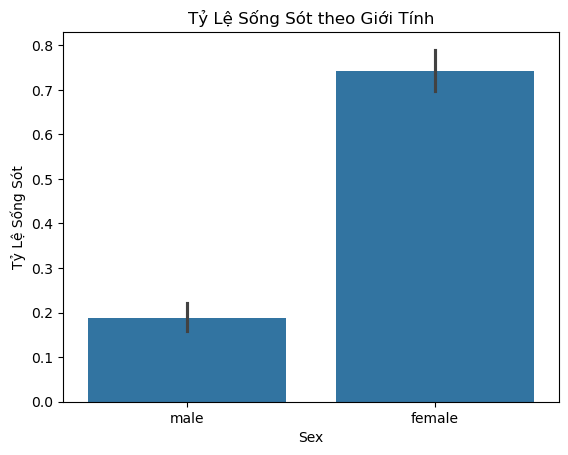

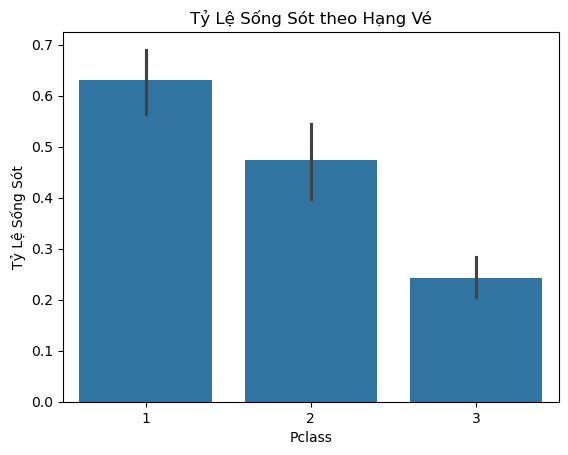

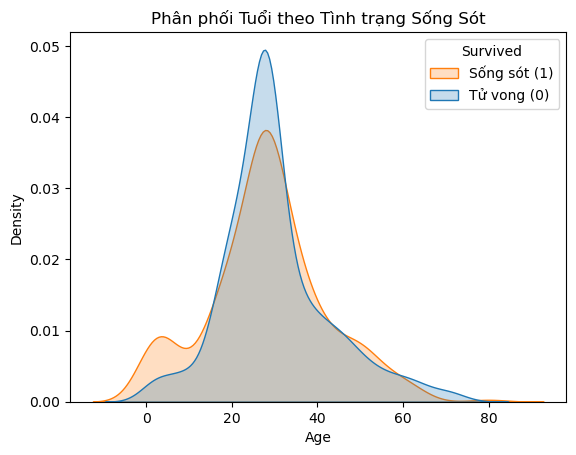

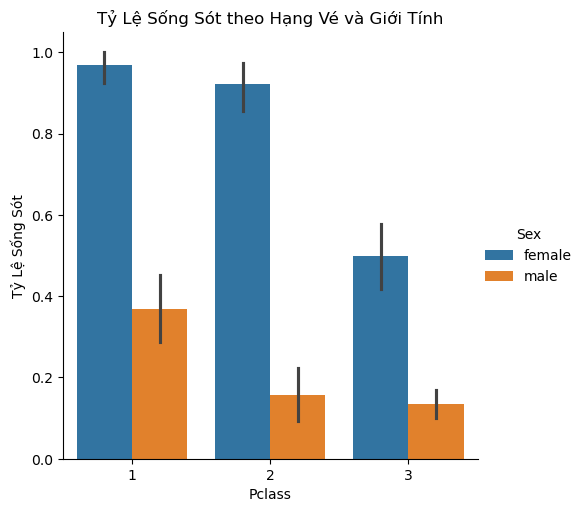

In [146]:
# Survived vs. Sex
sns.barplot(x='Sex', y='Survived', data=df_train)
plt.title('Tỷ Lệ Sống Sót theo Giới Tính')
plt.ylabel('Tỷ Lệ Sống Sót')
plt.show()
# Insight: Nữ giới có tỷ lệ sống sót cao hơn hẳn.

# Survived vs. Pclass
sns.barplot(x='Pclass', y='Survived', data=df_train)
plt.title('Tỷ Lệ Sống Sót theo Hạng Vé')
plt.ylabel('Tỷ Lệ Sống Sót')
plt.show()
# Insight: Hạng vé càng cao (1) thì tỷ lệ sống sót càng cao.

# Survived vs. Age (dùng KDE plot)
sns.kdeplot(data=df_train, x='Age', hue='Survived', fill=True, common_norm=False)
plt.title('Phân phối Tuổi theo Tình trạng Sống Sót')
plt.legend(title='Survived', labels=['Sống sót (1)', 'Tử vong (0)'])
plt.show()
# Insight: Có một đỉnh rõ rệt ở nhóm trẻ em (<10 tuổi) có tỷ lệ sống sót cao.

# Phân tích kết hợp: Survived vs. Pclass và Sex
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=df_train)
plt.title('Tỷ Lệ Sống Sót theo Hạng Vé và Giới Tính')
plt.ylabel('Tỷ Lệ Sống Sót')
plt.show()
# Insight: Nữ giới ở mọi hạng vé đều có tỷ lệ sống sót cao hơn nam giới. Nữ giới ở hạng 1 và 2 có tỷ lệ sống sót rất cao.

In [147]:
# Correlations:
data_corr = df_train.corr(method='pearson', numeric_only=True)

data_corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,0.019919
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.316912
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,-0.725541
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.240314
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.040460
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.036987
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.482075
Has_Cabin,0.019919,0.316912,-0.725541,0.240314,-0.040460,0.036987,0.482075,1.000000


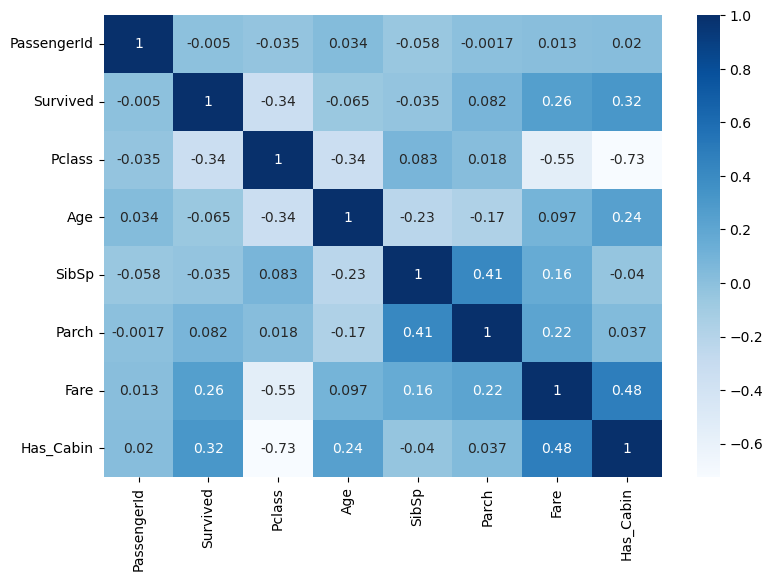

In [148]:
plt.figure(figsize=(9, 6))
sns.heatmap(data_corr, annot=True, cmap='Blues')
plt.show()

Nhận thấy rằng:
'fare' có tương quan (+) và pclass có tương quan (-) với 'Survived' → Giá vé càng cao hay loại vé càng cao cấp (càng thấp theo Ordical) thì tỉ lệ sống càng cao.
'fare' và 'pclass' có tương quan mạnh ngược, có nghĩa là vé càng cao cấp thì giá càng cao

### 2.4 Kỹ thuật đặc trưng

Đã tạo cột 'FamilySize'.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27416\3129027254.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df_train, palette='cubehelix')


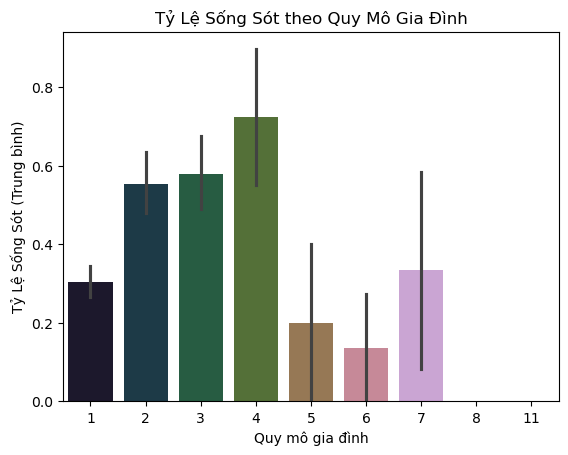

In [149]:
# Tạo cột FamilySize = SibSp (Anh chị em/Vợ chồng) + Parch (Bố mẹ/Con cái) + 1 (Bản thân)
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
print("Đã tạo cột 'FamilySize'.")

# Phân tích Survived vs. FamilySize
sns.barplot(x='FamilySize', y='Survived', data=df_train, palette='cubehelix')
plt.title('Tỷ Lệ Sống Sót theo Quy Mô Gia Đình')
plt.ylabel('Tỷ Lệ Sống Sót (Trung bình)')
plt.xlabel('Quy mô gia đình')
plt.show()

Biểu đồ này cho thấy tỷ lệ sống sót thay đổi như thế nào dựa trên số lượng thành viên gia đình đi cùng.

Insight: Những người đi một mình (FamilySize=1) hoặc đi với gia đình rất đông (FamilySize > 4) có xu hướng có tỷ lệ sống sót thấp hơn. Gia đình có quy mô vừa phải (2-4 người) dường như có tỷ lệ sống sót cao nhất.

Đã tạo cột 'IsAlone'.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27416\124706488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IsAlone', y='Survived', data=df_train, palette='Set2')


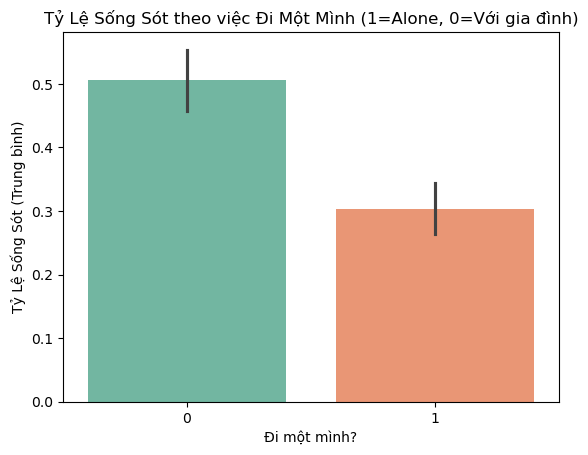

In [150]:
# Tạo cột IsAlone (Đi một mình)
df_train['IsAlone'] = 0 # Khởi tạo tất cả là 0 (không đi một mình)
df_train.loc[df_train['FamilySize'] == 1, 'IsAlone'] = 1 # Đặt là 1 nếu FamilySize = 1
print("Đã tạo cột 'IsAlone'.")

# Phân tích Survived vs. IsAlone
sns.barplot(x='IsAlone', y='Survived', data=df_train, palette='Set2')
plt.title('Tỷ Lệ Sống Sót theo việc Đi Một Mình (1=Alone, 0=Với gia đình)')
plt.ylabel('Tỷ Lệ Sống Sót (Trung bình)')
plt.xlabel('Đi một mình?')
plt.show()

Đã trích xuất các danh xưng từ cột 'Name'.

--- Các danh xưng và số lượng ban đầu ---
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

--- Các danh xưng và số lượng sau khi gộp ---
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27416\1901556635.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Title', y='Survived', data=df_train, palette='tab10')


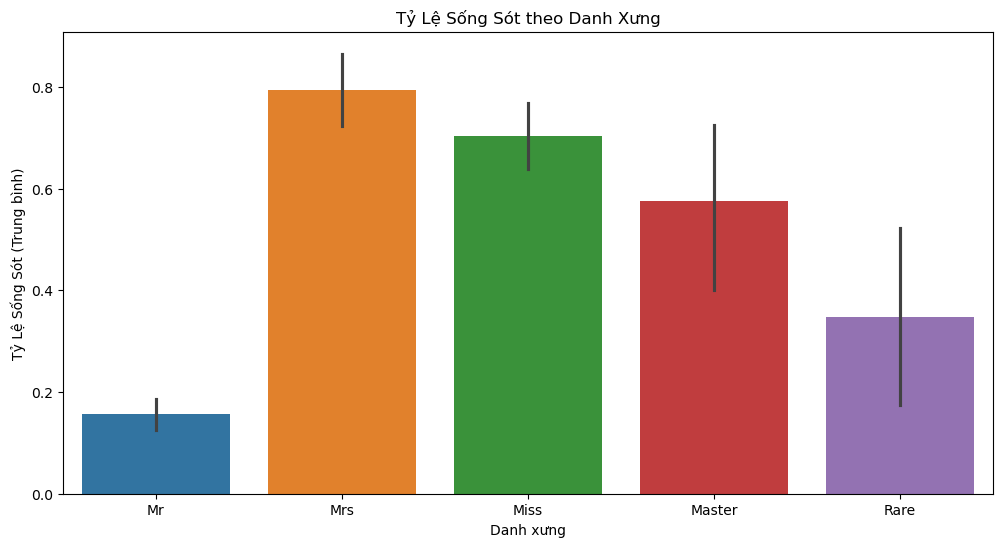

In [151]:
# Trích xuất danh xưng (Title) từ Name bằng regex
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

print("Đã trích xuất các danh xưng từ cột 'Name'.")

# Xem các loại danh xưng và số lượng
print("\n--- Các danh xưng và số lượng ban đầu ---")
print(df_train['Title'].value_counts())

# Gom nhóm các danh xưng ít gặp
for df in [df_train, df_test]:
    df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 
                                       'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print("\n--- Các danh xưng và số lượng sau khi gộp ---")
print(df_train['Title'].value_counts())

# Phân tích Survived vs. Title
plt.figure(figsize=(12, 6))
sns.barplot(x='Title', y='Survived', data=df_train, palette='tab10')
plt.title('Tỷ Lệ Sống Sót theo Danh Xưng')
plt.ylabel('Tỷ Lệ Sống Sót (Trung bình)')
plt.xlabel('Danh xưng')
plt.show()

Biểu đồ này hiển thị tỷ lệ sống sót của các nhóm danh xưng khác nhau.

Insight: Các danh xưng như Mrs (Phu nhân), Miss (Cô) và Master (Thiếu gia - thường là trẻ em nam) có tỷ lệ sống sót cao hơn đáng kể so với Mr (Ông). Nhóm Rare (hiếm) cũng có tỷ lệ sống sót khá tốt, có thể do họ là những người có địa vị cao. Điều này củng cố lại quan điểm "phụ nữ và trẻ em trước"

Đã tạo cột 'AgeGroup' từ cột 'Age'.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27416\3509548136.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup', y='Survived', data=df_train, palette='Spectral')


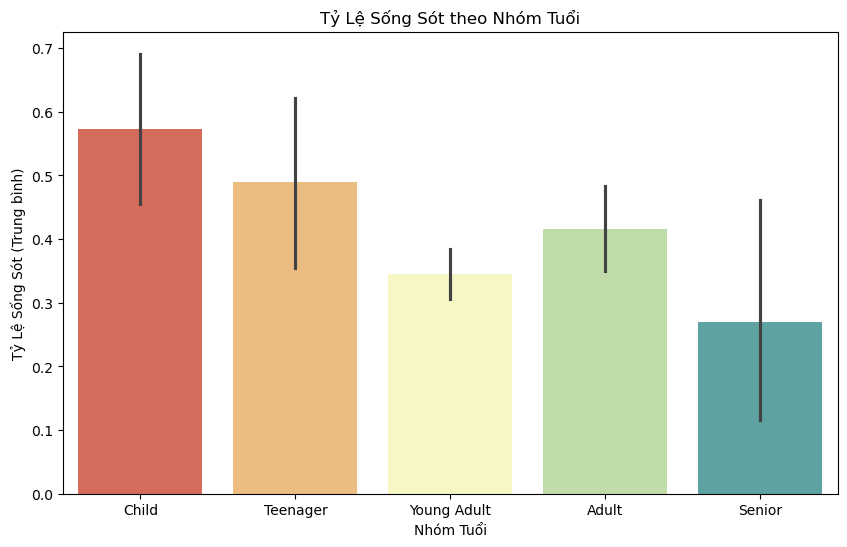

In [152]:
# Tạo các nhóm tuổi (bins)
age_bins = [0, 12, 18, 35, 60, 100] # Các mốc tuổi: 0-11, 12-17, 18-34, 35-59, 60+
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'] # Nhãn cho các nhóm
df_train['AgeGroup'] = pd.cut(df_train['Age'], bins=age_bins, labels=age_labels, right=False)
print("Đã tạo cột 'AgeGroup' từ cột 'Age'.")

# Phân tích Survived vs. AgeGroup
plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Survived', data=df_train, palette='Spectral')
plt.title('Tỷ Lệ Sống Sót theo Nhóm Tuổi')
plt.ylabel('Tỷ Lệ Sống Sót (Trung bình)')
plt.xlabel('Nhóm Tuổi')
plt.show()

## 2. Data Preprocessing

In [153]:

from sklearn.impute import SimpleImputer
# pandas was already imported in a previous cell; do not re-import here
num_imputer = SimpleImputer(strategy='median')
# ensure 1D assignment to the Series (avoid ValueError when assigning a 2D array)
df_train['Age'] = num_imputer.fit_transform(df_train[['Age']])[:, 0]
df_test['Age'] = num_imputer.transform(df_test[['Age']])[:, 0]

# === 2. Imputer cho cột phân loại (Embarked) ===
cat_imputer = SimpleImputer(strategy='most_frequent')
# convert 2D result to 1D when assigning back to a column
df_train['Embarked'] = cat_imputer.fit_transform(df_train[['Embarked']])[:, 0]
df_test['Embarked'] = cat_imputer.transform(df_test[['Embarked']])[:, 0]

In [154]:
print(df_train[['Age', 'Embarked']].isnull().sum())
print(df_test[['Age', 'Embarked']].isnull().sum())


Age         0
Embarked    0
dtype: int64
Age         0
Embarked    0
dtype: int64


In [155]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs


In [156]:
# Mã hóa các cột phân loại (drop_first=True tránh dư thừa)
df_train = pd.get_dummies(df_train, columns=['Sex', 'Embarked', 'Title'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Sex', 'Embarked', 'Title'], drop_first=True)


In [158]:
# StandardScaler was already imported earlier in the notebook, no need to re-import it here.
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'FamilySize']

# Ensure 'FamilySize' exists in both train and test before scaling
if 'FamilySize' not in df_train.columns:
	df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1

if 'FamilySize' not in df_test.columns:
	df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1

df_train[numerical_cols] = scaler.fit_transform(df_train[numerical_cols])
df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])


In [159]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Has_Cabin,FamilySize,IsAlone,AgeGroup,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,1,0,A/5 21171,-0.502445,0,0.059160,0,Young Adult,True,False,True,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,1,0,PC 17599,0.786845,1,0.059160,0,Adult,False,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0,0,STON/O2. 3101282,-0.488854,0,-0.560975,1,Young Adult,False,False,True,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,1,0,113803,0.420730,1,0.059160,0,Adult,False,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",0.433312,0,0,373450,-0.486337,0,-0.560975,1,Adult,True,False,True,False,True,False,False
